In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [56]:
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

## Unicos

In [57]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

## Duplicados

In [58]:
# Filas
df.duplicated(keep=False)[df.duplicated(keep=False)==True]

195    True
581    True
dtype: bool

In [59]:
# Columnas
df.T.duplicated()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

## Valores nulos

In [60]:
for cat in df.select_dtypes("object"):
    print("-"*40)
    print(cat)
    print("-"*40)
    print(df[cat].value_counts())

----------------------------------------
sex
----------------------------------------
sex
male      676
female    662
Name: count, dtype: int64
----------------------------------------
smoker
----------------------------------------
smoker
no     1064
yes     274
Name: count, dtype: int64
----------------------------------------
region
----------------------------------------
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [61]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Valores extremos

In [62]:
df.drop(columns="charges").iloc[:,0]

0       19
1       18
2       28
3       33
4       32
        ..
1333    50
1334    18
1335    18
1336    21
1337    61
Name: age, Length: 1338, dtype: int64

[]

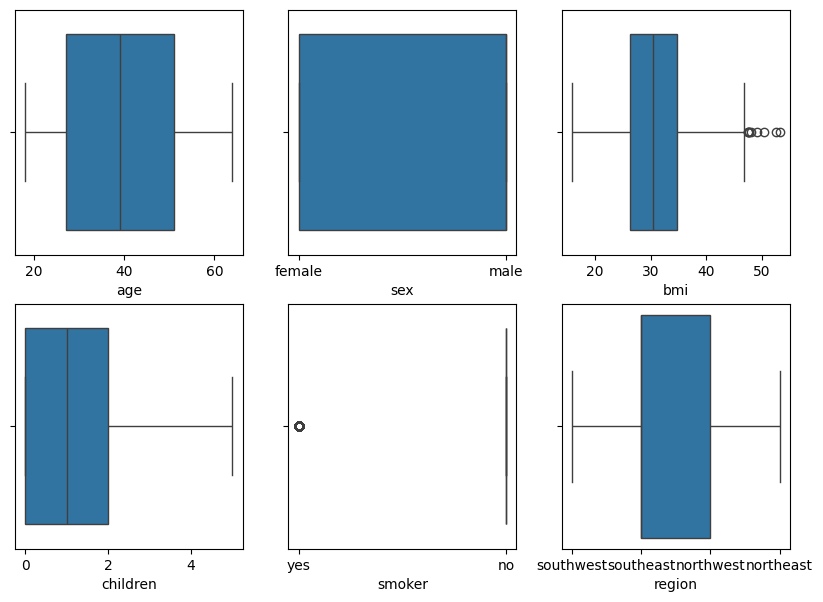

In [33]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

sns.boxplot(ax=axis[0,0], data=df, x=df.drop(columns="charges").columns[0])
sns.boxplot(ax=axis[0,1], data=df, x=df.drop(columns="charges").columns[1])
sns.boxplot(ax=axis[0,2], data=df, x=df.drop(columns="charges").columns[2])
sns.boxplot(ax=axis[1,0], data=df, x=df.drop(columns="charges").columns[3])
sns.boxplot(ax=axis[1,1], data=df, x=df.drop(columns="charges").columns[4])
sns.boxplot(ax=axis[1,2], data=df, x=df.drop(columns="charges").columns[5])

plt.plot()

## Categorización

In [63]:
df.select_dtypes("object")

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [64]:
df=pd.get_dummies(data=df, columns=df.select_dtypes("object").columns, drop_first=True, dtype=int)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   int64  
 5   smoker_yes        1338 non-null   int64  
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB


In [66]:
model=sm.OLS(df["charges"], sm.add_constant(df.drop(columns="charges"))).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:49:57   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
age                256.8564     11.899     21.587      0.000     233.514     280.199
bmi                339.1935     28.599     11.860      0.000     283.088     395.298
children           475.5005    137.804      3.451      0.001     205.163     745.838
sex_male          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker_yes        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region_northwest  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region_southeast -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region_southwest  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
model=sm.OLS(df["charges"], sm.add_constant(df.drop(columns=["charges", "sex_male", "region_northwest"]))).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.3
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:50:59   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.217e+04    949.538    -12.812      0.000    -1.4e+04   -1.03e+04
age                257.0064     11.889     21.617      0.000     233.683     280.330
bmi                338.6413     28.554     11.860      0.000     282.625     394.657
children           471.5441    137.656      3.426      0.001     201.498     741.590
smoker_yes        2.384e+04    411.659     57.921      0.000     2.3e+04    2.47e+04
region_southeast  -858.4696    415.206     -2.068      0.039   -1672.998     -43.941
region_southwest  -782.7452    413.756     -1.892      0.059   -1594.430      28.940
==============================================================================
Omnibus:                      300.125   Durbin-Watson:                   2.092
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              716.587
Skew:                           1.211   Prob(JB):                    2.48e-156
Kurtosis:                       5.643   Cond. No.                         295.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

[]

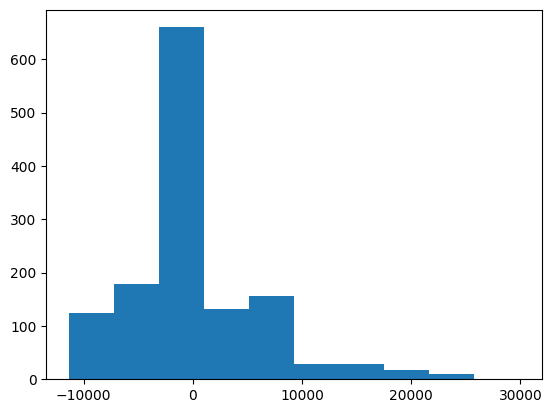

In [69]:
plt.hist(model.resid)
plt.plot()

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Usamos BayesianRidge porque es rápido y robusto
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=0)

# Ajustar y transformar (Solo numéricas)
X_train_imputed = imputer.fit_transform(X_train_numerico)